<a href="https://colab.research.google.com/github/kayleendo/Project-1-Wrangling-EDA-kNN/blob/main/DS_3001_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).

### Part 1: Wrangling and EDA (40/100 pts)




1.

In [ ]:
# Download packages
import pandas as pd
import numpy as np

2.

In [8]:
# Setup: Writing a function data directly from website to use with all of our data imports.
# This is so that our code actually runs whenever graders run it.
import requests

def load_data(url, temp_path, filetype):
    # Download the file
    response = requests.get(url)
    response.raise_for_status()

    with open(temp_path, "wb") as f:
        f.write(response.content)

    if filetype == "csv":
        return pd.read_csv(temp_path)
    elif filetype == "sas":
        return pd.read_sas(temp_path, format="xport")


# 1.) Starting off with loading DEMO.xpt (NHANES 1999-2000 from CDC  website)
gdf = load_data("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/DEMO.xpt",
                "/tmp/DEMO.xpt", "sas")

# 2.) Loading LMF from github
mdf = load_data("https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/refs/heads/main/data/linked_mortality_file_1999_2000.csv",
                "/tmp/linked_mortality_file_1999_2000.csv", "csv")

# Merge into one df
df = gdf.merge(mdf, on="SEQN", how="inner")
df.head(2)

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,RIDRETH2,...,WTIREP50,WTIREP51,WTIREP52,ELIGSTAT,MORTSTAT,UCOD_LEADING,DIABETES,HYPERTEN,PERMTH_INT,PERMTH_EXM
0,1.0,1.0,2.0,2.0,2.0,2.0,29.0,31.0,4.0,2.0,...,10327.992682,9809.165049,10323.315747,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1.0,2.0,2.0,1.0,77.0,926.0,926.0,3.0,1.0,...,27268.025234,27406.383620,26984.812909,1,1.0,6.0,0.0,0.0,177.0,177.0


3.

1. **ELIGSTAT** indicates mortality likage eligibility. A value of 1
indicates that the survey participant was eligible for the mortality linkage, a value of 2 indicates the survey participant was unger the age of 18 and therefore not eligible for public release, and a value of 3 indicates the survey participant was not eligible due to possessing insufficient identifying data to conduct data linkage. Because Linkage Mortality Files only include mortality information for survey participants aged 18 and older, minors will have an ELIGSTAT value of 2 and will have missing values for all other mortality or follow-up variables.
2. **MORTSTAT** refers to the determination of vital status. It is the mortality status at the end of follow-up for survey participants who are linkage eligible. Each survey participants eligible is assigned a vital status code (0= assumed alive, 1= assumed deceased). Vital status can be identified by crossing MORTSTAT
and the leading cause of death variable, UCOD_LEADING. However, in a small number of cases UCOD_LEADING was also missing from the death
certificate record. For participants who are not linkage eligible, MORTSTAT is coded as a
numeric missing value.
3. **PERMTH_INT** indicates the follow-up time that has been calculated using person
months from the date of interview to the date of death or the end of the mortality period (for 1999-2018 NHANES and NHANES III).  
4. **RIDAGEEX** indicates the survey participant's age at the time of their medical examination in years. It is a continous numeric variable.

4.

We downloaded Body Measures (BMX), Blood Pressure (BPX), Smoking (SMQ), and Cholesterol (LAB13). These variables were selected because they represent known mortality risk factors. Age, smoking, obesity, and cholesterol levels are all strongly associated with mortality.

In [9]:
# 1.) Loading BMX data
bmx = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BMX.xpt", "/tmp/BMX.xpt", "sas")

# 2.) Loading BPX data
bpx = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/BPX.xpt", "/tmp/BPX.xpt", "sas")

# 3.) Loading SMQ data
smq = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/SMQ.xpt", "/tmp/SMQ.xpt","sas")

# 4.) Loading LAB13 data
lab = load_data ("https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/LAB13.xpt", "/tmp/LAB13.xpt", "sas")

In [10]:
# Combine the datasets into one complete dataframe
mortality = gdf.merge(mdf, on="SEQN", how="inner")
mortality = mortality.merge(bmx, on="SEQN", how="left")
mortality = mortality.merge(smq, on="SEQN", how="left")
mortality = mortality.merge(bpx, on="SEQN", how="left")
mortality = mortality.merge(lab, on="SEQN", how="left")

In [11]:
# Document the missing values
mortality.isna().sum().sort_values(ascending=False)

,0
BMAUPREL,9965
BMAUPLEL,9965
BMIHEAD,9964
BMALLKNE,9964
DMARACE,9963
...,...
WTMEC4YR,0
SDDSRVYR,0
SDMVSTRA,0
SDJ1REPN,0


5.

In [12]:
import urllib.request
import os
import zipfile
import os


def download_data(force=False):
   """Download and extract course data from Zenodo."""


   zip_path = 'data.zip'
   data_dir = './data'


   if not os.path.exists(zip_path) or force:
       print("Downloading course data...")
       urllib.request.urlretrieve(
           'https://zenodo.org/records/18235955/files/data.zip?download=1',
           zip_path
       )
       print("Download complete")


   if not os.path.exists(data_dir) or force:
       print("Extracting data files...")
       with zipfile.ZipFile(zip_path, 'r') as zip_ref:
           zip_ref.extractall(data_dir)
       print("Data extracted")


   return data_dir




if __name__ == "__main__":
   download_data()

In [13]:
df.isna().sum().sort_values(ascending=False) #identifies what variables are missing the most values

,0
DMAETHN,9963
DMARACE,9963
DIABETES,8291
UCOD_LEADING,8291
HYPERTEN,8291
...,...
WTIREP48,0
WTIREP47,0
WTIREP46,0
WTIREP52,0


In [14]:
df["MORTSTAT"].value_counts() #mortality distribution ( who is/how many people alive or dead)

,count
MORTSTAT,
0.0,3770
1.0,1675


In [15]:
df["SURVIVAL_YEARS"] = df["PERMTH_INT"] / 12 #survival time after exam made into years instead of months
df["AGE_YEARS"] = df["RIDAGEEX"] / 12  #age at exam made into years instead of months

In [16]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(20)#what top 20 variables are missing the most values

,0
DMAETHN,9963
DMARACE,9963
DIABETES,8291
UCOD_LEADING,8291
HYPERTEN,8291
RIDPREG,8136
DMDYRSUS,8067
RIDEXPRG,8003
DMDHSEDU,6733
DMDSCHOL,6654


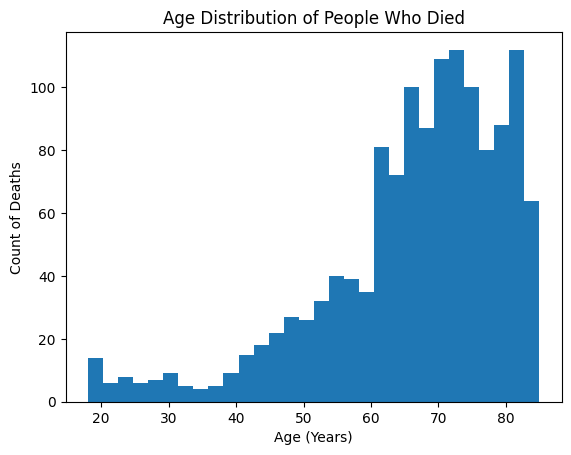

In [20]:
import matplotlib.pyplot as plt
plt.hist(df.loc[df["MORTSTAT"] == 1, "AGE_YEARS"].dropna(), bins=30) #histogram age distribution of people who died
plt.title("Age Distribution of People Who Died")
plt.xlabel("Age (Years)")
plt.ylabel("Count of Deaths")
plt.show()

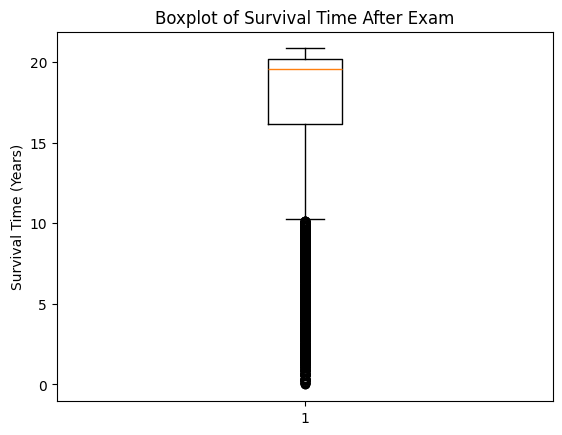

In [21]:
plt.boxplot(df["SURVIVAL_YEARS"].dropna())  #outliers or early deaths of survival time overall with individuals
plt.title("Boxplot of Survival Time After Exam")
plt.ylabel("Survival Time (Years)")
plt.show()

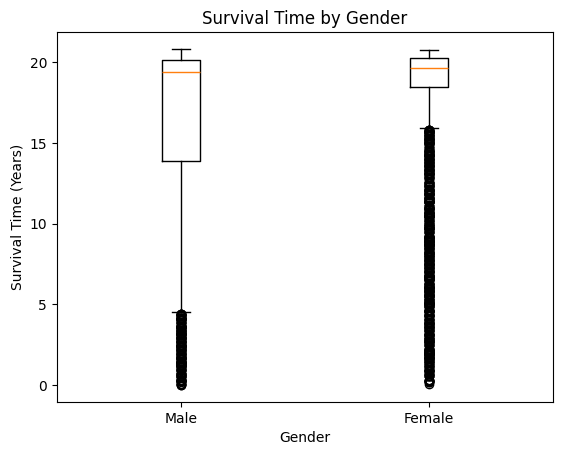

In [29]:
male_survival = df.loc[df["RIAGENDR"] == 1, "SURVIVAL_YEARS"].dropna()  #Get survival years for males and remove missing values
female_survival = df.loc[df["RIAGENDR"] == 2, "SURVIVAL_YEARS"].dropna() #Get survival years for females and remove missing values


plt.boxplot([male_survival, female_survival], tick_labels=["Male", "Female"]) #Make a boxplot to compare survival time for males and females

plt.title("Survival Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Time (Years)")
plt.show()

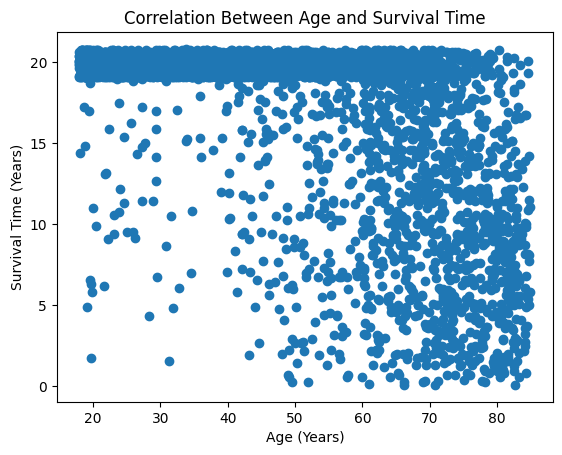

In [23]:
plt.scatter(df["AGE_YEARS"], df["SURVIVAL_YEARS"]) #scatterplot of age vs survival time
plt.title("Correlation Between Age and Survival Time")
plt.xlabel("Age (Years)")
plt.ylabel("Survival Time (Years)")
plt.show()

In [25]:
pd.crosstab(df["RIDRETH1"], df["MORTSTAT"]) #contingency table for race and mortality


MORTSTAT,0.0,1.0
RIDRETH1,,
1.0,1185,366
2.0,264,73
3.0,1458,871
4.0,715,320
5.0,148,45


In [26]:
pd.crosstab(df["RIDRETH1"], df["HYPERTEN"]) #contingency table between race and those who have hypertension


HYPERTEN,0.0,1.0
RIDRETH1,,
1.0,284,82
2.0,61,12
3.0,750,120
4.0,264,56
5.0,36,9


Overall, examining the data revealed that the first thing noted was the number of variables with substantial missing data. The variables with the most missing data values were race, ethnicity, diabetes, cause of death, and blood pressure status. It concerns us the most that values are missing from race and ethnicity because without those details, it blocks the amount of insight that is important for examining life expectancies in certain demographics. An additional change we made was converting the age and time duration data from months to years to better aid analysis and visualization.

The histogram shows that the deaths are skewed left. Therefore, that insight highlights how most individuals will pass away at older ages, indicating mortality risk increases with age. Based on the boxplot, it is evident that individuals (regardless of gender) live, on average, 16-20 years after their examination. However, some people will die earlier, such as in 1-10 years. This is important to note because they may already have existing health conditions, which could lead to a higher mortality rate. It is important that this information is considered because it may highlight and contextualize the disparities that certain individuals from certain communities may be at risk of experiencing. Possibly leading to future preventative measures and an assessment of one's quality of life.


It was found that, despite survival time and gender being correlated, their correlation is weak.   It is noted that females have slightly longer survival times of 18-19 years than males, who have 17-18 years, based on median survival after examinations. A stronger correlation between two variables is between age and survival time. As age increases, survival time decreases. This means that, after their examination, it is observed that younger people live longer than older people. This type of relationship is called negative correlation.


The contingency table comparing race and hypertension highlights how the majority of individuals across all races do not have hypertension, despite it still being present in every group. This is insightful because it raises awareness of hypertension and overall health in communities. Additionally, race and mortality are inversely related, indicating that most individuals are alive at the end of the study and follow-up period.




















### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)
2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)
3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)
5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)

1. This data set includes information from the National Health and Nutrition Examination Survey (NHANES) and stores background, socioeconomic, and medical information about individuals who completed household interviews between 1999 and 2000. It contains individual-level information such as age, gender, race/ethnicity, and country of birth. The data set also includes household and family-level information such as household size and total family income. Medical information, such as body measures, blood pressure, smoking habits, and cholesterol, is only stored for individuals with sufficient identifying data or individuals over the age of 18.

Each row represents an observation of an individual who completed the household interview. Each observation has a unique data release number (SDDSRVYR), and all variable data in the row describes that one individual.

Missing data for individuals limits or data analysis to adults, as many key variables are not displayed for minors. This means our results will only apply to adult populations. Additional, many observations are missing a mortality status. Without a known mortality outcome, we are unable to include those individuals in our analyses. This makes these rows unusable, and reduces our sample size.

This data was collected by the NHANES, which is conduted by the National Center for Health Statistics (NCHS), and is a part of the Centers for Disease Control and Prevention (CDC). The NHAHES is a nationally representative survey of the US population, and is used to asses the health and well being of the population. The CDC uses these results to monitor health trends and to track disparities across different demographic groups.



2. We selected Age (RIDAGEYR), Body Mass Index (BMXBMI), Total Cholesterol (LBXTC), and Smoking Status (SMQ020) to predict our target, Mortality Status (MORTSTAT). These specific variables were selected because they represent well-known mortality risk factors and are all strongly associated with life expectancy. From the describe table, we found that there is a lot of missing data for most columns, to address this, we found the average of each row and replaced missing data with that value, additionally, there are some significant outliers for BMI , Cholesterol, and also a 9 value for Smoking, which doesn't make sense since it should either be 1 or 2. The Kernel density plot shows that the ages aren't evenly distributed across ages, heavily weighted towards younger population. From the scatterplot, we see a very weak positive correlation betweeen age and cholesterol. From the condition kernal density plot, there is a small tendency towards a higher bmi from deceased individuals.

In [ ]:
# Define your list of variables
var_list = ['MORTSTAT', 'RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']

# Create the smaller dataframe
mortality_small = mortality.loc[:, var_list]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Describe Table:
print(mortality_small.describe())

# Kernel Density: Shows the smooth distribution of age
sns.kdeplot(data=mortality_small, x='RIDAGEYR')
plt.title("Kernel Density of Age")
plt.show()

# Scatter Plot: Shows how relationship between age and total cholesterol
sns.scatterplot(data=mortality_small, x='RIDAGEYR', y='LBXTC', alpha=0.3)
plt.title("Scatter Plot: Age vs. Total Cholesterol")
plt.show()

# Conditional Kernel Density: Shows a BMI seperated by Morality Status
sns.kdeplot(data=mortality_small, x='BMXBMI', hue='MORTSTAT', common_norm=False)
plt.title("BMI Distribution Conditioned by Mortality Status")
plt.show()

In [ ]:
# Replace the missing (NaN) values with that average
mortality_small['BMXBMI'] = mortality_small['BMXBMI'].fillna(mortality_small['BMXBMI'].mean())
mortality_small['LBXTC'] = mortality_small['LBXTC'].fillna(mortality_small['LBXTC'].mean())
mortality_small['SMQ020'] = mortality_small['SMQ020'].fillna(mortality_small['SMQ020'].mean())

# Drop any row that has missing data
mortality_clean = mortality_small.dropna().copy()

print(mortality_clean.describe())



In [ ]:
import numpy as np

# Drop extreme BMI outliers (keep the bottom 99%)
q99_bmi = np.quantile(mortality_clean['BMXBMI'], .99)
keep_bmi = mortality_clean['BMXBMI'] < q99_bmi
mortality_clean = mortality_clean.loc[keep_bmi, :]

# Drop extreme Cholesterol outliers (keep the bottom 99%)
q99_chol = np.quantile(mortality_clean['LBXTC'], .99)
keep_chol = mortality_clean['LBXTC'] < q99_chol
mortality_clean = mortality_clean.loc[keep_chol, :]

# Keep rows where smoking is exactly 1 OR 2
keep_smoking = (mortality_clean['SMQ020'] == 1) | (mortality_clean['SMQ020'] == 2)
mortality_clean = mortality_clean.loc[keep_smoking, :]

mortality_clean.describe()

3. We used a k-Nearest Neighbor (kNN) classifier to predict mortality (MORTSTAT) from age (RIDAGEYR), BMI (BMXBMI), total cholesterol (LBXTC), and smoking status (SMQ020). All features were scaled to 0–1 using a Min-Max scaler. The data were split into 80% training and 20% test sets. To select the optimal number of neighbors (k), we tested odd values from 3 to 301 and measured training and test accuracy. Small k values overfit the training data, while large k values underfit. Test accuracy peaked around k ≈ 35–65 with a maximum accuracy of approximately 0.747, which we selected as the best k. This demonstrates the bias-variance tradeoff and provides the model with the best performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Define X and y
X = mortality_clean[['RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']]
y = mortality_clean['MORTSTAT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define k values to test
k_grid = np.array([ (2*k+3) for k in range(0,150) ])  # 3, 5, 7, ..., 301

train_accuracies = []
test_accuracies = []

# Loop through k values
for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f'k={k}: Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}')

# Plot training vs test accuracy
plt.figure(figsize=(12,6))
sns.lineplot(x=k_grid, y=train_accuracies, label='Training Accuracy')
sns.lineplot(x=k_grid, y=test_accuracies, label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('kNN Training vs Test Accuracy')
plt.show()

# Find optimal k
test_accuracies = np.array(test_accuracies)
optimal_indices = np.where(test_accuracies == np.max(test_accuracies))
k_optimal = k_grid[optimal_indices]

print(f"Optimal k value(s): {k_optimal}")
print(f"Maximum test accuracy: {test_accuracies[optimal_indices][0]:.3f}")


4. Using your variables to predict life expectancy using a  𝑘 -Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select  𝑘 . (10/100 pts)

We used a k-Nearest Neighbor (kNN) classifier to predict life expectancy in months (PERMTH_INT) from age (RIDAGEYR), BMI (BMXBMI), total cholesterol (LBXTC), and smoking status (SMQ020). All features were scaled to 0–1 using a Min-Max scaler. The data were split into 80% training and 20% test sets. To select the optimal number of neighbors (k), we tested odd values from 3 to 301 and measured RMSE and R^2. Test accuracy peaked like before at around k ≈ 35–50 with a min RMSE of 50.274 at k=31, which we selected as the best k. This also demonstrates the bias-variance tradeoff and provides the model with the best performance on unseen data.

In [ ]:
# First: clean life expectancy data

# Create list of vars to analyze
var_list = ['MORTSTAT', 'RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020', 'PERMTH_INT']
life_expectancy = mortality.loc[:, var_list]

# Replace the missing (NaN) values with averages
life_expectancy['BMXBMI'] = life_expectancy['BMXBMI'].fillna(life_expectancy['BMXBMI'].mean())
life_expectancy['LBXTC'] = life_expectancy['LBXTC'].fillna(life_expectancy['LBXTC'].mean())
life_expectancy['SMQ020'] = life_expectancy['SMQ020'].fillna(life_expectancy['SMQ020'].mean())

# Drop any row that has missing data
life_expectancy_clean = life_expectancy.dropna().copy()

# Drop extreme BMI outliers (keep the bottom 99%)
q99_bmi = np.quantile(life_expectancy_clean['BMXBMI'], .99)
keep_bmi = life_expectancy_clean['BMXBMI'] < q99_bmi
life_expectancy_clean = life_expectancy_clean.loc[keep_bmi, :]

# Drop extreme Cholesterol outliers (keep the bottom 99%)
q99_chol = np.quantile(life_expectancy_clean['LBXTC'], .99)
keep_chol = life_expectancy_clean['LBXTC'] < q99_chol
life_expectancy_clean = life_expectancy_clean.loc[keep_chol, :]

# Keep rows where smoking is exactly 1 OR 2
keep_smoking = (life_expectancy_clean['SMQ020'] == 1) | (life_expectancy_clean['SMQ020'] == 2)
life_expectancy_clean = life_expectancy_clean.loc[keep_smoking, :]

life_expectancy_clean.describe()

In [ ]:
# Now actually do KNN regression

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define X and y
X = life_expectancy_clean[['RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']]
y = life_expectancy_clean['PERMTH_INT']

# Drop missing values just in case
knn_data = X.copy()
knn_data['PERMTH_INT'] = y
knn_data = knn_data.dropna()

X = knn_data[['RIDAGEYR', 'BMXBMI', 'LBXTC', 'SMQ020']]
y = knn_data['PERMTH_INT']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define k values to test
max_k = min(301, len(X_train))
k_grid = np.array([k for k in range(3, max_k + 1, 2)])  # odd k only

train_rmse = []
test_rmse = []
train_r2 = []
test_r2 = []

# Loop through k values
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    train_r2.append(r2_score(y_train, y_train_pred))
    test_r2.append(r2_score(y_test, y_test_pred))

    print(
        f'k={k}: '
        f'Train RMSE={train_rmse[-1]:.3f}, Test RMSE={test_rmse[-1]:.3f}, '
        f'Train R2={train_r2[-1]:.3f}, Test R2={test_r2[-1]:.3f}'
    )

# Plot RMSE
plt.figure(figsize=(12, 6))
plt.plot(k_grid, train_rmse, label='Training RMSE')
plt.plot(k_grid, test_rmse, label='Test RMSE')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.title('kNN Regression: Training vs Test RMSE')
plt.legend()
plt.show()

# Find optimal k based on lowest test RMSE
test_rmse = np.array(test_rmse)
optimal_index = np.argmin(test_rmse)
k_optimal = k_grid[optimal_index]

print(f"Optimal k value: {k_optimal}")
print(f"Minimum test RMSE: {test_rmse[optimal_index]:.3f}")
print(f"Test R2 at optimal k: {test_r2[optimal_index]:.3f}")

5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)

We could use our models to come up with rough estimates of whether patients will die in the next year and their life expectancy according to select attributes (whether they smoke, their age, BMI, and total cholestrol). This could be used to triage what patients may need preventative care the most urgently to improve those attributes, allowing hospitals to do proper resource allocation and patients that are most in need of care to receive it.

Of course, given that we only use those 4 variables in our regressions, this is an incredibly limited and inaccurate model. For mortality, our training set accuracy maxes out at 86%, meaning that there are 14% of people whose mortality statuses in the next year do not predict correctly. Our life expectancy regression is even worse: only 49.9% of the variation in life expectancy is explained by our best model (k=31). 

This means that we must only treat our estimates as directional as best: i.e as general indications that someone may or may not need preventative care, instead of numbers that we tell patients. We should never say "this model predicts you have 14 months to live," because we are nowhere close to knowing for sure, and such a prediction could be much more harmful to a patient by inciting fear than helpful.